In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [40]:
data = pd.read_csv("housing.csv")

In [42]:
print(data.head(), data.tail())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished          price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
561  1820000  3000 

In [44]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566 entries, 0 to 565
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             566 non-null    int64 
 1   area              566 non-null    int64 
 2   bedrooms          566 non-null    int64 
 3   bathrooms         566 non-null    int64 
 4   stories           566 non-null    int64 
 5   mainroad          566 non-null    object
 6   guestroom         566 non-null    object
 7   basement          566 non-null    object
 8   hotwaterheating   566 non-null    object
 9   airconditioning   566 non-null    object
 10  parking           566 non-null    int64 
 11  prefarea          566 non-null    object
 12  furnishingstatus  566 non-null    object
dtypes: int64(6), object(7)
memory usage: 57.6+ KB
None


In [46]:
print(data.describe())

              price          area    bedrooms   bathrooms     stories  \
count  5.660000e+02    566.000000  566.000000  566.000000  566.000000   
mean   4.666197e+06   5076.773852    2.950530    1.275618    1.786219   
std    1.906052e+06   2168.049072    0.746217    0.496008    0.861294   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.360000e+06   3514.000000    2.000000    1.000000    1.000000   
50%    4.270000e+06   4500.000000    3.000000    1.000000    2.000000   
75%    5.639375e+06   6357.500000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  566.000000  
mean     0.674912  
std      0.856194  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [48]:
print("Missing values:", data.isnull().sum())
print("Duplicates:", data.duplicated().sum())


Missing values: price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
Duplicates: 21


In [60]:
data.drop_duplicates(inplace=True)

In [64]:
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = data[column].fillna(data[column].mode()[0])  # Fill categorical with mode
    else:
        data[column] = data[column].fillna(data[column].median())  # Fill numeric with median

In [66]:
categorical_columns = data.select_dtypes(include=['object']).columns
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

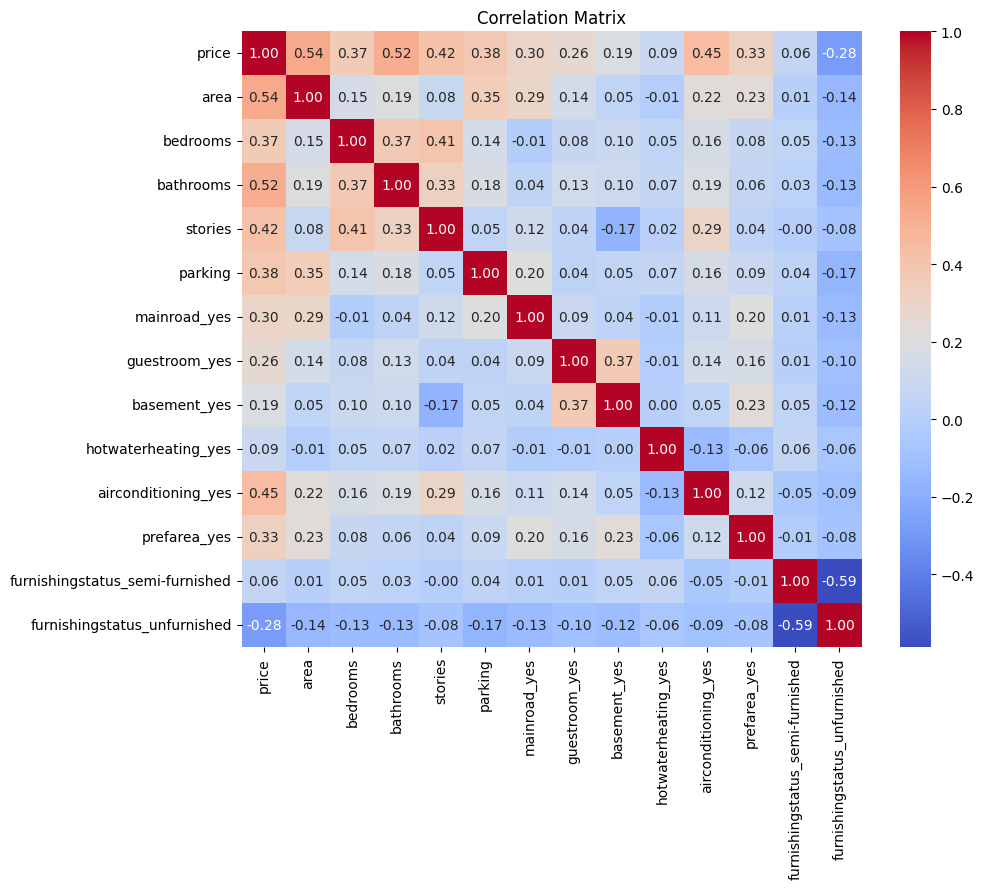

In [68]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

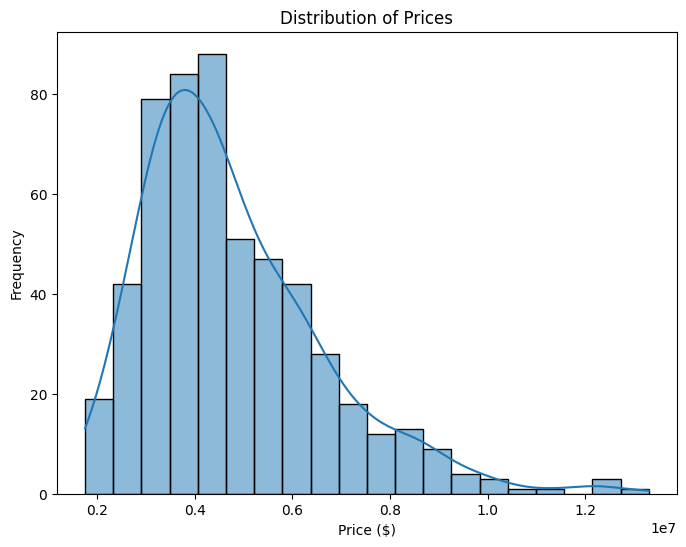

In [72]:
plt.figure(figsize=(8, 6))
sns.histplot(data['price'], bins=20, kde=True)  # Replace 'price_column'
plt.title("Distribution of Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

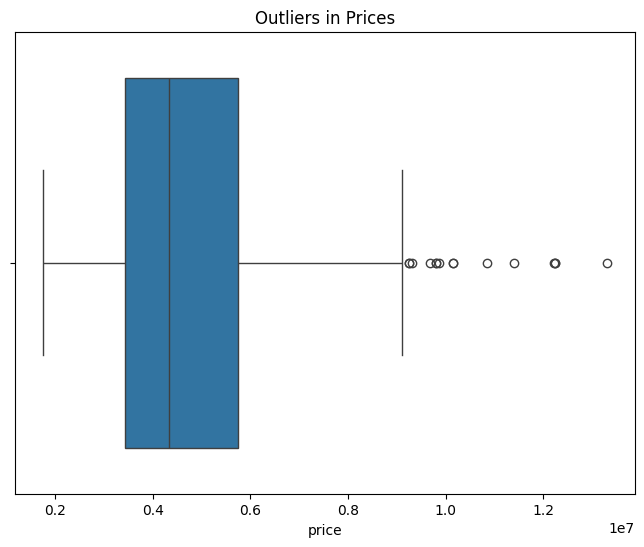

In [76]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x='price')  # Replace 'price_column'
plt.title("Outliers in Prices")
plt.show()

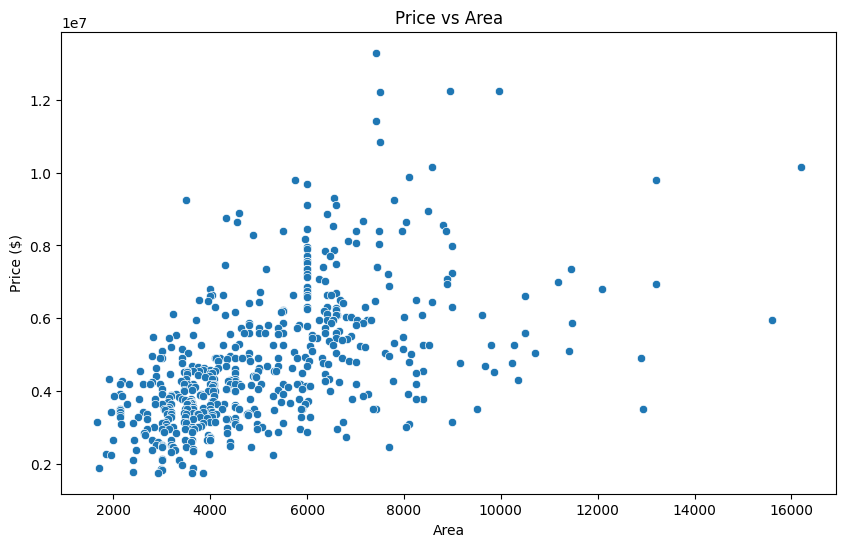

In [80]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='area', y='price')  # Replace placeholders
plt.title("Price vs Area")
plt.xlabel("Area")
plt.ylabel("Price ($)")
plt.show()